In [7]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

from scipy import stats

In [6]:
ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")

In [8]:
df= pd.concat([ethiopia, kenya, nigeria, sudan, tanzania])

In [11]:
df.head()
df["Country"].value_counts()

Country
Kenya       8216
Nigeria     4108
Sudan       4108
Tanzania    4108
Name: count, dtype: int64

In [12]:
df["DATE"] = pd.to_datetime(df["DATE"])
df["Year"] = df["DATE"].dt.year
df["Month"] = df["DATE"].dt.month

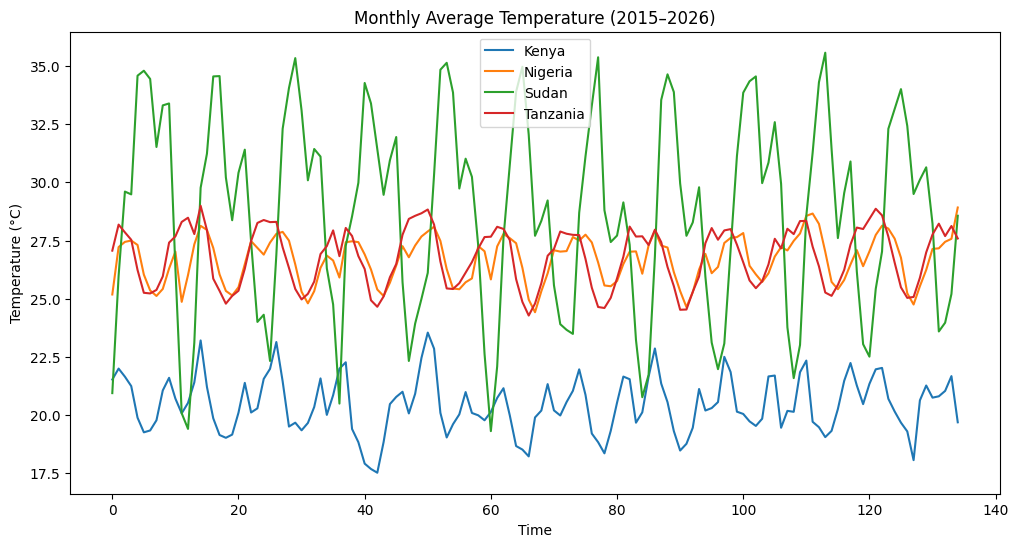

In [13]:
monthly_temp = df.groupby(["Country", "Year", "Month"])["T2M"].mean().reset_index()

plt.figure(figsize=(12,6))

for country in monthly_temp["Country"].unique():
    subset = monthly_temp[monthly_temp["Country"] == country]
    plt.plot(range(len(subset)), subset["T2M"], label=country)

plt.title("Monthly Average Temperature (2015–2026)")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

In [14]:
temp_summary = df.groupby("Country")["T2M"].agg(["mean", "median", "std"])
temp_summary

,mean,median,std
Country,,,
Kenya,20.427483,20.36,1.438194
Nigeria,26.659160,26.82,1.115192
Sudan,28.759607,29.16,4.679431
Tanzania,26.802458,26.99,1.325279


kenya shows highest mean temprature

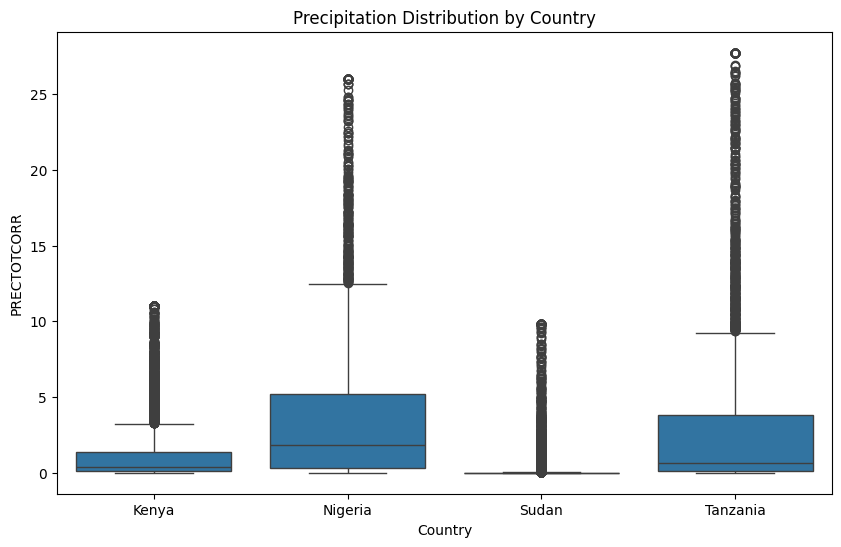

In [15]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Country", y="PRECTOTCORR")
plt.title("Precipitation Distribution by Country")
plt.show()

In [16]:
precip_summary = df.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"])
precip_summary

,mean,median,std
Country,,,
Kenya,1.323742,0.38,2.282693
Nigeria,3.950704,1.84,5.454583
Sudan,0.487103,0.00,1.665770
Tanzania,3.420823,0.64,6.002178


In [17]:
extreme_heat = df[df["T2M_MAX"] > 35]

heat_count = extreme_heat.groupby(["Country", "Year"]).size().reset_index(name="ExtremeHeatDays")

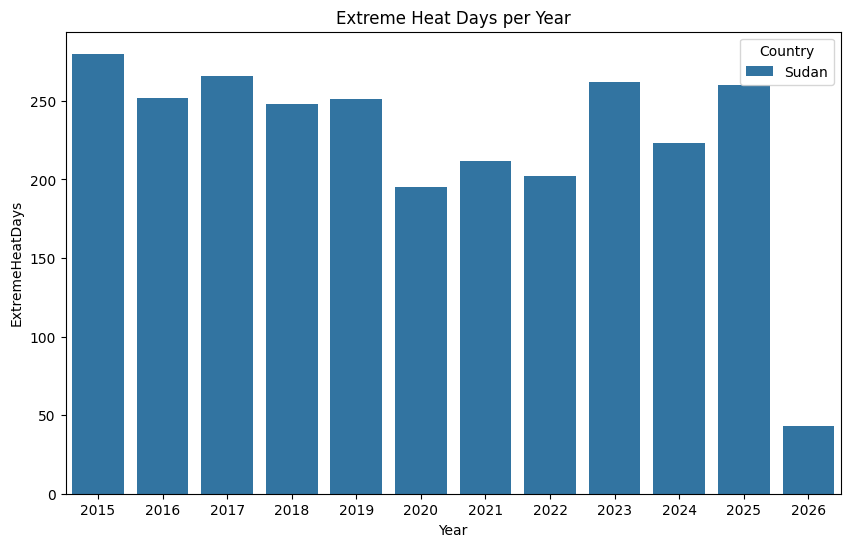

In [18]:
plt.figure(figsize=(10,6))
sns.barplot(data=heat_count, x="Year", y="ExtremeHeatDays", hue="Country")
plt.title("Extreme Heat Days per Year")
plt.show()

In [19]:
df["Dry"] = df["PRECTOTCORR"] < 1

In [20]:
def max_dry_streak(group):
    streak = 0
    max_streak = 0
    
    for val in group:
        if val:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0
            
    return max_streak

dry_streaks = df.groupby(["Country", "Year"])["Dry"].apply(max_dry_streak).reset_index(name="MaxDryStreak")

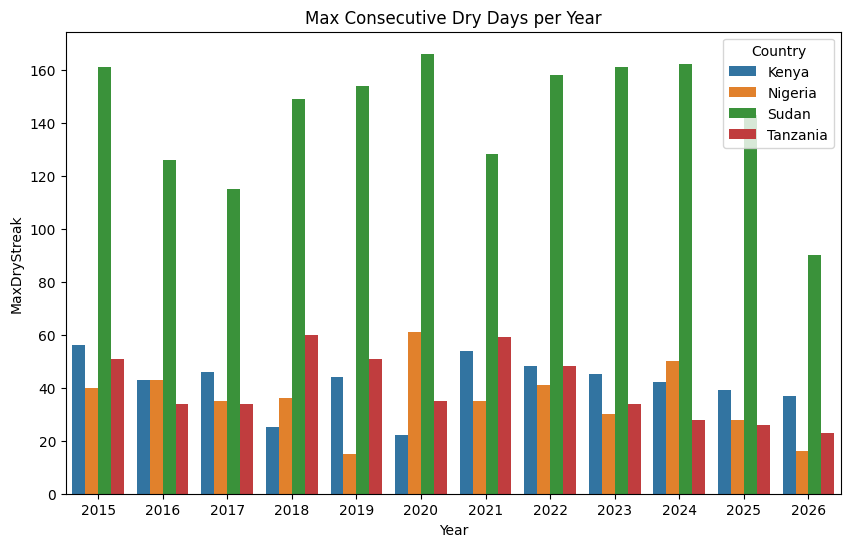

In [21]:
plt.figure(figsize=(10,6))
sns.barplot(data=dry_streaks, x="Year", y="MaxDryStreak", hue="Country")
plt.title("Max Consecutive Dry Days per Year")
plt.show()

In [22]:
groups = [df[df["Country"] == c]["T2M"].dropna() for c in df["Country"].unique()]

f_stat, p_value = stats.f_oneway(*groups)

print("F-stat:", f_stat)
print("P-value:", p_value)

F-stat: 14435.223081669272
P-value: 0.0


In [24]:
vulnerability = pd.DataFrame({
    "TempMean": temp_summary["mean"],
    "TempStd": temp_summary["std"],
    "RainStd": precip_summary["std"],
    "ExtremeHeat": heat_count.groupby("Country")["ExtremeHeatDays"].mean(),
    "DryStreak": dry_streaks.groupby("Country")["MaxDryStreak"].mean()
})

vulnerability["Score"] = (
    vulnerability["TempStd"] +
    vulnerability["RainStd"] +
    vulnerability["ExtremeHeat"] +
    vulnerability["DryStreak"]
)

vulnerability = vulnerability.sort_values("Score", ascending=False)

vulnerability

,TempMean,TempStd,RainStd,ExtremeHeat,DryStreak,Score
Country,,,,,,
Sudan,28.759607,4.679431,1.665770,224.5,142.750000,373.595201
Kenya,20.427483,1.438194,2.282693,NaN,41.750000,NaN
Nigeria,26.659160,1.115192,5.454583,NaN,35.833333,NaN
Tanzania,26.802458,1.325279,6.002178,NaN,40.250000,NaN
